In [1]:
import gc
import zlib
import json
import hashlib
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from pathlib import Path
from scipy import ndimage
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any
from skimage import measure, morphology, segmentation


In [2]:
PROJECT_ROOT = Path(r"F:/AstraZeneca/project/chestCT/CHEST_CT_NSCLC")

LUNA_ROOT = PROJECT_ROOT / "data" / "raw" / "LUNA"

LUNA_ANNOTATIONS_PATH = LUNA_ROOT / "annotations.csv"
LUNA_CANDIDATES_PATH = LUNA_ROOT / "candidates.csv"
LUNA_CANDIDATES_V2_ZIP_PATH = LUNA_ROOT / "candidates_V2.zip"

# subset0.zip - subset9.zip
LUNA_SUBSET_ZIPS = sorted(
    LUNA_ROOT.glob("subset*.zip"),
    key=lambda x: int("".join(filter(str.isdigit, x.stem)) or -1)
)

# output
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
LUNA_TABLE_DIR = PROCESSED_DIR / "tables" / "luna16"
LUNA_FIGURE_DIR = PROCESSED_DIR / "figures" / "luna16"
LUNA_QC_FIGURE_DIR = LUNA_FIGURE_DIR / "preprocessing_qc"

# Optional full-volume output folder
LUNA_PREPROCESSED_VOLUME_DIR = PROCESSED_DIR / "luna16_preprocessed_volumes"

for p in [LUNA_TABLE_DIR, LUNA_FIGURE_DIR, LUNA_QC_FIGURE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("LUNA_ROOT:", LUNA_ROOT)
print("LUNA_TABLE_DIR:", LUNA_TABLE_DIR)
print("LUNA_FIGURE_DIR:", LUNA_FIGURE_DIR)

PROJECT_ROOT: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC
LUNA_ROOT: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LUNA
LUNA_TABLE_DIR: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\tables\luna16
LUNA_FIGURE_DIR: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\figures\luna16


In [3]:
# Preprocessing parameters
TARGET_SPACING_XYZ = np.array([1.0, 1.0, 1.0], dtype=np.float32)

HU_CLIP_MIN = -1000
HU_CLIP_MAX = 400

# Common operational threshold for lung air-like region
LUNG_THRESHOLD_HU = -320

# None means process all selected scans.
# Recommended first validation: 5, 10, or 20.
# Full run: None
MAX_SCANS_TO_PREPROCESS = 10

# If True, process scans that have nodule annotations first.
PROCESS_ONLY_SCANS_WITH_NODULES_FIRST = True

# Keep False if disk space is limited.
# True will save compressed preprocessed image and lung mask as .npz.
SAVE_FULL_PREPROCESSED_VOLUME = False

# Number of QC figures to save
MAX_QC_FIGURES = 20

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("TARGET_SPACING_XYZ:", TARGET_SPACING_XYZ)
print("MAX_SCANS_TO_PREPROCESS:", MAX_SCANS_TO_PREPROCESS)
print("SAVE_FULL_PREPROCESSED_VOLUME:", SAVE_FULL_PREPROCESSED_VOLUME)

TARGET_SPACING_XYZ: [1. 1. 1.]
MAX_SCANS_TO_PREPROCESS: 10
SAVE_FULL_PREPROCESSED_VOLUME: False


In [4]:
print("LUNA_ROOT exists:", LUNA_ROOT.exists(), LUNA_ROOT)

print("\nCSV files:")
print("annotations.csv exists:", LUNA_ANNOTATIONS_PATH.exists(), LUNA_ANNOTATIONS_PATH)
print("candidates.csv exists:", LUNA_CANDIDATES_PATH.exists(), LUNA_CANDIDATES_PATH)
print("candidates_V2.zip exists:", LUNA_CANDIDATES_V2_ZIP_PATH.exists(), LUNA_CANDIDATES_V2_ZIP_PATH)

print("\nSubset zip files:")
print("Number of subset zip files:", len(LUNA_SUBSET_ZIPS))
for z in LUNA_SUBSET_ZIPS:
    print(" -", z.name)

LUNA_ROOT exists: True F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LUNA

CSV files:
annotations.csv exists: True F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LUNA\annotations.csv
candidates.csv exists: True F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LUNA\candidates.csv
candidates_V2.zip exists: True F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LUNA\candidates_V2.zip

Subset zip files:
Number of subset zip files: 10
 - subset0.zip
 - subset1.zip
 - subset2.zip
 - subset3.zip
 - subset4.zip
 - subset5.zip
 - subset6.zip
 - subset7.zip
 - subset8.zip
 - subset9.zip


In [5]:
annotations = pd.read_csv(LUNA_ANNOTATIONS_PATH)
candidates = pd.read_csv(LUNA_CANDIDATES_PATH)

print("annotations shape:", annotations.shape)
display(annotations.head())

print("candidates shape:", candidates.shape)
display(candidates.head())

annotations shape: (1186, 5)


,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150


candidates shape: (551065, 5)


,seriesuid,coordX,coordY,coordZ,class
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-56.08,-67.85,-311.92,0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,53.21,-244.41,-245.17,0
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.66,-121.80,-286.62,0
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-33.66,-72.75,-308.41,0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-32.25,-85.36,-362.51,0


In [6]:
def read_csv_from_zip(zip_path: Path) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path, "r") as z:
        csv_files = [name for name in z.namelist() if name.lower().endswith(".csv")]
        print("CSV files inside zip:", csv_files)

        if len(csv_files) == 0:
            raise FileNotFoundError(f"No CSV file found inside {zip_path}")

        with z.open(csv_files[0]) as f:
            df = pd.read_csv(f)

    return df


if LUNA_CANDIDATES_V2_ZIP_PATH.exists():
    candidates_v2 = read_csv_from_zip(LUNA_CANDIDATES_V2_ZIP_PATH)
    print("candidates_v2 shape:", candidates_v2.shape)
    display(candidates_v2.head())
else:
    candidates_v2 = None
    print("candidates_V2.zip not found.")

CSV files inside zip: ['candidates_V2.csv']
candidates_v2 shape: (754975, 5)


,seriesuid,coordX,coordY,coordZ,class
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,68.420000,-74.480000,-288.700000,0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-95.209361,-91.809406,-377.426350,0
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-24.766755,-120.379294,-273.361539,0
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-63.080000,-65.740000,-344.240000,0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,52.946688,-92.688873,-241.067872,0


In [7]:
print("Annotation columns:")
print(annotations.columns.tolist())

print("\nMissing values:")
display(annotations.isna().sum())

print("\nTotal annotated nodules:", len(annotations))
print("Unique CT scans with annotated nodules:", annotations["seriesuid"].nunique())

print("\nNodule diameter statistics:")
display(annotations["diameter_mm"].describe())

annotation_stats = {
    "num_annotated_nodules": int(len(annotations)),
    "num_unique_scans_with_nodules": int(annotations["seriesuid"].nunique()),
    "diameter_mean_mm": float(annotations["diameter_mm"].mean()),
    "diameter_std_mm": float(annotations["diameter_mm"].std()),
    "diameter_min_mm": float(annotations["diameter_mm"].min()),
    "diameter_q25_mm": float(annotations["diameter_mm"].quantile(0.25)),
    "diameter_median_mm": float(annotations["diameter_mm"].median()),
    "diameter_q75_mm": float(annotations["diameter_mm"].quantile(0.75)),
    "diameter_max_mm": float(annotations["diameter_mm"].max()),
    "missing_values": annotations.isna().sum().to_dict()
}

with open(LUNA_TABLE_DIR / "annotation_stats.json", "w", encoding="utf-8") as f:
    json.dump(annotation_stats, f, indent=4)

annotation_stats

Annotation columns:
['seriesuid', 'coordX', 'coordY', 'coordZ', 'diameter_mm']

Missing values:


seriesuid      0
coordX         0
coordY         0
coordZ         0
diameter_mm    0
dtype: int64


Total annotated nodules: 1186
Unique CT scans with annotated nodules: 601

Nodule diameter statistics:


count    1186.000000
mean        8.306527
std         4.762033
min         3.253443
25%         5.107177
50%         6.433600
75%         9.696301
max        32.270030
Name: diameter_mm, dtype: float64

{'num_annotated_nodules': 1186,
 'num_unique_scans_with_nodules': 601,
 'diameter_mean_mm': 8.306527315553964,
 'diameter_std_mm': 4.762032807179365,
 'diameter_min_mm': 3.253443196,
 'diameter_q25_mm': 5.1071767445,
 'diameter_median_mm': 6.433600479000001,
 'diameter_q75_mm': 9.696301457499999,
 'diameter_max_mm': 32.27003025,
 'missing_values': {'seriesuid': 0,
  'coordX': 0,
  'coordY': 0,
  'coordZ': 0,
  'diameter_mm': 0}}

In [8]:
def diameter_group(d):
    if d < 6:
        return "<6mm"
    elif d < 8:
        return "6-8mm"
    elif d < 15:
        return "8-15mm"
    else:
        return ">=15mm"


annotations["diameter_group"] = annotations["diameter_mm"].apply(diameter_group)

diameter_group_summary = (
    annotations["diameter_group"]
    .value_counts()
    .rename_axis("diameter_group")
    .reset_index(name="count")
)

diameter_group_summary["percentage"] = (
    diameter_group_summary["count"] / len(annotations) * 100
).round(2)

display(diameter_group_summary)

diameter_group_summary.to_csv(
    LUNA_TABLE_DIR / "diameter_group_summary.csv",
    index=False
)

,diameter_group,count,percentage
0,<6mm,502,42.33
1,8-15mm,281,23.69
2,6-8mm,276,23.27
3,>=15mm,127,10.71


In [9]:
nodules_per_scan = (
    annotations.groupby("seriesuid")
    .size()
    .reset_index(name="nodule_count")
    .sort_values("nodule_count", ascending=False)
)

display(nodules_per_scan.head(20))

print("Nodules per scan statistics:")
display(nodules_per_scan["nodule_count"].describe())

nodules_per_scan.to_csv(
    LUNA_TABLE_DIR / "nodules_per_scan.csv",
    index=False
)

,seriesuid,nodule_count
142,1.3.6.1.4.1.14519.5.2.1.6279.6001.176030616406...,12
441,1.3.6.1.4.1.14519.5.2.1.6279.6001.328789598898...,9
186,1.3.6.1.4.1.14519.5.2.1.6279.6001.195557219224...,9
201,1.3.6.1.4.1.14519.5.2.1.6279.6001.202187810895...,9
239,1.3.6.1.4.1.14519.5.2.1.6279.6001.219428004988...,9
275,1.3.6.1.4.1.14519.5.2.1.6279.6001.239358021703...,8
21,1.3.6.1.4.1.14519.5.2.1.6279.6001.112767175295...,8
408,1.3.6.1.4.1.14519.5.2.1.6279.6001.309955999522...,7
581,1.3.6.1.4.1.14519.5.2.1.6279.6001.910435939545...,7
360,1.3.6.1.4.1.14519.5.2.1.6279.6001.280072876841...,7


Nodules per scan statistics:


count    601.000000
mean       1.973378
std        1.483000
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       12.000000
Name: nodule_count, dtype: float64

In [10]:
candidate_class_summary = (
    candidates["class"]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
)

candidate_class_summary["percentage"] = (
    candidate_class_summary["count"] / len(candidates) * 100
).round(4)

display(candidate_class_summary)

candidate_class_summary.to_csv(
    LUNA_TABLE_DIR / "candidate_class_summary.csv",
    index=False
)

,class,count,percentage
0,0,549714,99.7548
1,1,1351,0.2452


In [11]:
subset_zip_summary = []

for zip_path in LUNA_SUBSET_ZIPS:
    with zipfile.ZipFile(zip_path, "r") as z:
        names = z.namelist()

        mhd_files = [n for n in names if n.lower().endswith(".mhd")]
        raw_files = [n for n in names if n.lower().endswith(".raw")]
        zraw_files = [n for n in names if n.lower().endswith(".zraw")]

        subset_zip_summary.append({
            "zip_file": zip_path.name,
            "num_mhd": len(mhd_files),
            "num_raw": len(raw_files),
            "num_zraw": len(zraw_files),
            "total_files": len(names)
        })

subset_zip_df = pd.DataFrame(subset_zip_summary)
display(subset_zip_df)

subset_zip_df.to_csv(
    LUNA_TABLE_DIR / "subset_zip_file_counts.csv",
    index=False
)

,zip_file,num_mhd,num_raw,num_zraw,total_files
0,subset0.zip,89,89,0,178
1,subset1.zip,89,89,0,178
2,subset2.zip,89,89,0,178
3,subset3.zip,89,89,0,178
4,subset4.zip,89,89,0,178
5,subset5.zip,89,89,0,178
6,subset6.zip,89,89,0,178
7,subset7.zip,89,89,0,178
8,subset8.zip,88,88,0,176
9,subset9.zip,88,88,0,176


In [12]:
def parse_number_list(value: str, dtype=float):
    return [dtype(x) for x in value.replace(",", " ").split()]


def parse_mhd_header_from_zip(zip_path: Path, mhd_name: str):
    with zipfile.ZipFile(zip_path, "r") as z:
        text = z.read(mhd_name).decode("utf-8", errors="ignore")

    header = {}

    for line in text.splitlines():
        line = line.strip()
        if "=" in line:
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    return header


def build_luna_metadata_from_zips(subset_zips):
    metadata_rows = []

    for subset_zip in tqdm(subset_zips, desc="Reading .mhd headers"):
        with zipfile.ZipFile(subset_zip, "r") as z:
            mhd_names = [n for n in z.namelist() if n.lower().endswith(".mhd")]

        for mhd_name in mhd_names:
            header = parse_mhd_header_from_zip(subset_zip, mhd_name)

            dim_size = parse_number_list(header.get("DimSize", "0 0 0"), int)
            spacing = parse_number_list(header.get("ElementSpacing", "0 0 0"), float)

            origin_text = header.get("Offset", header.get("Position", "0 0 0"))
            origin = parse_number_list(origin_text, float)

            transform_text = header.get("TransformMatrix", "1 0 0 0 1 0 0 0 1")
            transform = parse_number_list(transform_text, float)

            metadata_rows.append({
                "seriesuid": Path(mhd_name).stem,
                "subset_zip": subset_zip.name,
                "mhd_name": mhd_name,
                "raw_file": header.get("ElementDataFile"),

                "size_x": dim_size[0],
                "size_y": dim_size[1],
                "size_z": dim_size[2],

                "spacing_x": spacing[0],
                "spacing_y": spacing[1],
                "spacing_z": spacing[2],

                "origin_x": origin[0],
                "origin_y": origin[1],
                "origin_z": origin[2],

                "transform_00": transform[0],
                "transform_01": transform[1],
                "transform_02": transform[2],
                "transform_10": transform[3],
                "transform_11": transform[4],
                "transform_12": transform[5],
                "transform_20": transform[6],
                "transform_21": transform[7],
                "transform_22": transform[8],

                "element_type": header.get("ElementType"),
                "compressed_data": header.get("CompressedData", "False"),
                "byte_order_msb": header.get("ElementByteOrderMSB", "False"),
            })

    return pd.DataFrame(metadata_rows)


metadata_df = build_luna_metadata_from_zips(LUNA_SUBSET_ZIPS)

print("Total CT scans found from zip metadata:", len(metadata_df))
display(metadata_df.head())

metadata_df.to_csv(
    LUNA_TABLE_DIR / "ct_metadata_from_zip.csv",
    index=False
)

Reading .mhd headers: 100%|██████████| 10/10 [00:02<00:00,  3.76it/s]

Total CT scans found from zip metadata: 888


,seriesuid,subset_zip,mhd_name,raw_file,size_x,size_y,size_z,spacing_x,spacing_y,spacing_z,...,transform_02,transform_10,transform_11,transform_12,transform_20,transform_21,transform_22,element_type,compressed_data,byte_order_msb
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,subset0.zip,subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.1057...,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,512,512,121,0.761719,0.761719,2.500,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,MET_SHORT,False,False
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896...,subset0.zip,subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.1081...,1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896...,512,512,119,0.742188,0.742188,2.500,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,MET_SHORT,False,False
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,subset0.zip,subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.1090...,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,512,512,161,0.548828,0.548828,1.250,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,MET_SHORT,False,False
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.111172165674...,subset0.zip,subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.1111...,1.3.6.1.4.1.14519.5.2.1.6279.6001.111172165674...,512,512,538,0.742188,0.742188,0.625,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,MET_SHORT,False,False
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.122763913896...,subset0.zip,subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.1227...,1.3.6.1.4.1.14519.5.2.1.6279.6001.122763913896...,512,512,124,0.615234,0.615234,2.500,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,MET_SHORT,False,False


In [13]:
print("Spacing statistics:")
display(metadata_df[["spacing_x", "spacing_y", "spacing_z"]].describe())

print("CT size statistics:")
display(metadata_df[["size_x", "size_y", "size_z"]].describe())

Spacing statistics:


,spacing_x,spacing_y,spacing_z
count,888.000000,888.000000,888.000000
mean,0.689530,0.689530,1.569538
std,0.084574,0.084574,0.725174
min,0.460938,0.460938,0.450000
25%,0.625000,0.625000,1.000000
50%,0.703125,0.703125,1.250000
75%,0.742188,0.742188,2.500000
max,0.976562,0.976562,2.500000


CT size statistics:


,size_x,size_y,size_z
count,888.0,888.0,888.000000
mean,512.0,512.0,255.884009
std,0.0,0.0,133.761188
min,512.0,512.0,95.000000
25%,512.0,512.0,137.750000
50%,512.0,512.0,237.500000
75%,512.0,512.0,305.000000
max,512.0,512.0,764.000000


In [14]:
ct_seriesuids = set(metadata_df["seriesuid"])
annotation_seriesuids = set(annotations["seriesuid"])

missing_ct_for_annotations = sorted(annotation_seriesuids - ct_seriesuids)
ct_without_annotations = sorted(ct_seriesuids - annotation_seriesuids)

matching_summary = {
    "ct_scans_found_in_subset_zips": int(len(ct_seriesuids)),
    "scans_with_annotations": int(len(annotation_seriesuids)),
    "annotations_without_matching_ct": int(len(missing_ct_for_annotations)),
    "ct_scans_without_annotated_nodules": int(len(ct_without_annotations)),
}

print(json.dumps(matching_summary, indent=4))

with open(LUNA_TABLE_DIR / "matching_summary.json", "w", encoding="utf-8") as f:
    json.dump(matching_summary, f, indent=4)

pd.DataFrame({"seriesuid": missing_ct_for_annotations}).to_csv(
    LUNA_TABLE_DIR / "missing_ct_for_annotations.csv",
    index=False
)

pd.DataFrame({"seriesuid": ct_without_annotations}).to_csv(
    LUNA_TABLE_DIR / "ct_without_annotations.csv",
    index=False
)

{
    "ct_scans_found_in_subset_zips": 888,
    "scans_with_annotations": 601,
    "annotations_without_matching_ct": 0,
    "ct_scans_without_annotated_nodules": 287
}


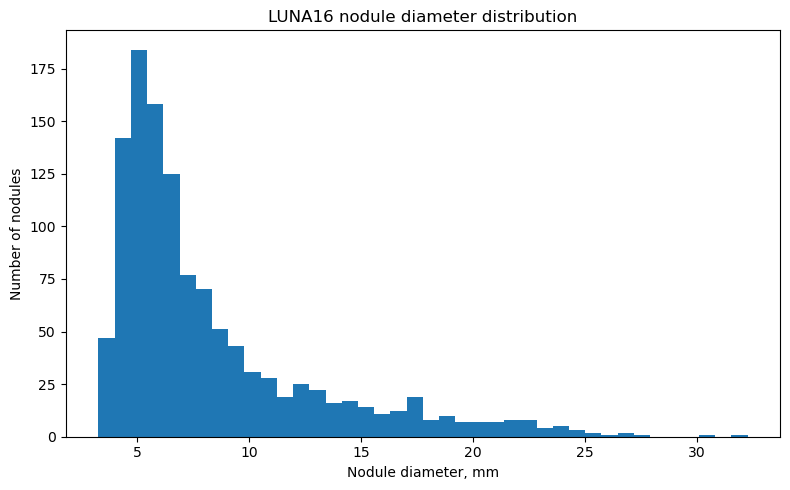

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(annotations["diameter_mm"], bins=40)
plt.xlabel("Nodule diameter, mm")
plt.ylabel("Number of nodules")
plt.title("LUNA16 nodule diameter distribution")
plt.tight_layout()
plt.savefig(LUNA_FIGURE_DIR / "nodule_diameter_distribution.png", dpi=300)
plt.show()

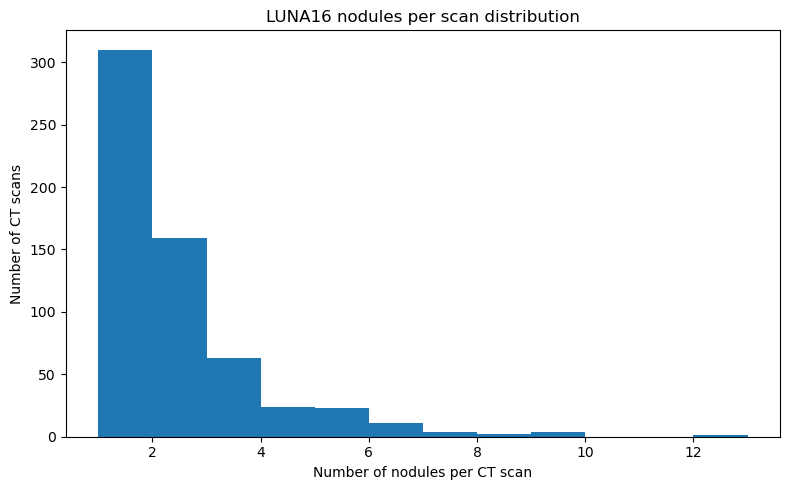

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(
    nodules_per_scan["nodule_count"],
    bins=range(1, int(nodules_per_scan["nodule_count"].max()) + 2)
)
plt.xlabel("Number of nodules per CT scan")
plt.ylabel("Number of CT scans")
plt.title("LUNA16 nodules per scan distribution")
plt.tight_layout()
plt.savefig(LUNA_FIGURE_DIR / "nodules_per_scan_distribution.png", dpi=300)
plt.show()

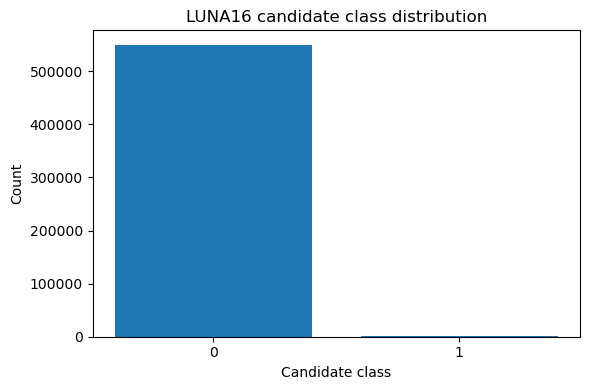

In [17]:
plt.figure(figsize=(6, 4))
plt.bar(candidate_class_summary["class"].astype(str), candidate_class_summary["count"])
plt.xlabel("Candidate class")
plt.ylabel("Count")
plt.title("LUNA16 candidate class distribution")
plt.tight_layout()
plt.savefig(LUNA_FIGURE_DIR / "candidate_class_distribution.png", dpi=300)
plt.show()

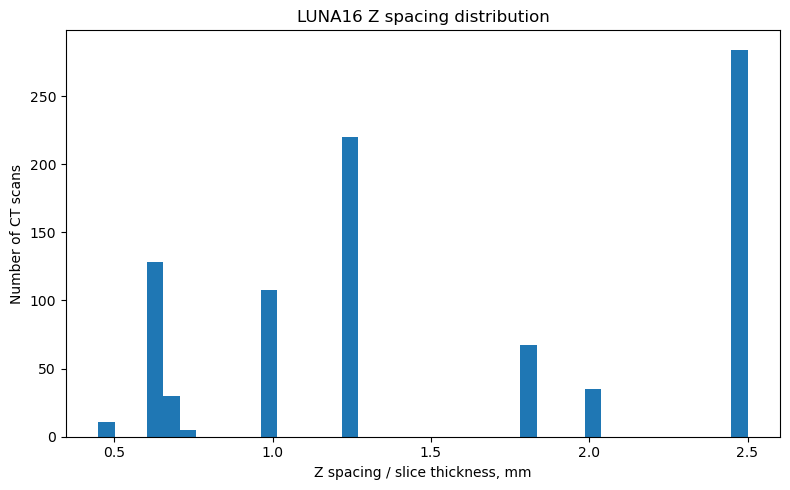

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(metadata_df["spacing_z"], bins=40)
plt.xlabel("Z spacing / slice thickness, mm")
plt.ylabel("Number of CT scans")
plt.title("LUNA16 Z spacing distribution")
plt.tight_layout()
plt.savefig(LUNA_FIGURE_DIR / "z_spacing_distribution.png", dpi=300)
plt.show()

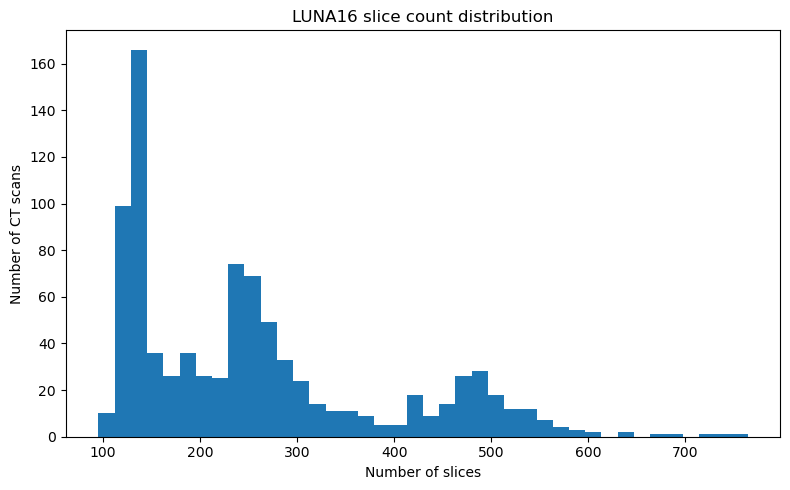

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(metadata_df["size_z"], bins=40)
plt.xlabel("Number of slices")
plt.ylabel("Number of CT scans")
plt.title("LUNA16 slice count distribution")
plt.tight_layout()
plt.savefig(LUNA_FIGURE_DIR / "slice_count_distribution.png", dpi=300)
plt.show()

In [20]:
basic_report_path = LUNA_TABLE_DIR / "luna16_basic_eda_report.md"

with open(basic_report_path, "w", encoding="utf-8") as f:
    f.write("# LUNA16 Basic EDA Report\n\n")

    f.write("## File audit\n\n")
    f.write(f"- Number of subset zip files: {len(subset_zip_df)}\n")
    f.write(f"- CT scans found from .mhd metadata: {len(metadata_df)}\n")
    f.write(f"- Annotation rows: {len(annotations)}\n")
    f.write(f"- Candidate rows: {len(candidates)}\n\n")

    f.write("## Annotation statistics\n\n")
    f.write(f"- Unique scans with annotated nodules: {annotations['seriesuid'].nunique()}\n")
    f.write(f"- Total annotated nodules: {len(annotations)}\n")
    f.write(f"- Mean nodule diameter: {annotations['diameter_mm'].mean():.2f} mm\n")
    f.write(f"- Median nodule diameter: {annotations['diameter_mm'].median():.2f} mm\n")
    f.write(f"- Min nodule diameter: {annotations['diameter_mm'].min():.2f} mm\n")
    f.write(f"- Max nodule diameter: {annotations['diameter_mm'].max():.2f} mm\n\n")

    f.write("## Diameter group summary\n\n")
    f.write(diameter_group_summary.to_csv(index=False))
    f.write("\n")

    f.write("## Candidate class distribution\n\n")
    f.write(candidate_class_summary.to_csv(index=False))
    f.write("\n")

    f.write("## CT metadata summary\n\n")
    f.write(f"- Mean z spacing: {metadata_df['spacing_z'].mean():.3f} mm\n")
    f.write(f"- Median z spacing: {metadata_df['spacing_z'].median():.3f} mm\n")
    f.write(f"- Mean number of slices: {metadata_df['size_z'].mean():.2f}\n")
    f.write(f"- Median number of slices: {metadata_df['size_z'].median():.2f}\n\n")

    f.write("## Matching check\n\n")
    for k, v in matching_summary.items():
        f.write(f"- {k}: {v}\n")

print("Saved:", basic_report_path)

Saved: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\tables\luna16\luna16_basic_eda_report.md


In [21]:
def sha1_anonymise(value: str, prefix: str = "luna") -> str:
    digest = hashlib.sha1(value.encode("utf-8")).hexdigest()[:12]
    return f"{prefix}_{digest}"


def get_numpy_dtype(element_type: str, byte_order_msb: bool = False) -> np.dtype:
    type_map = {
        "MET_CHAR": "i1",
        "MET_UCHAR": "u1",
        "MET_SHORT": "i2",
        "MET_USHORT": "u2",
        "MET_INT": "i4",
        "MET_UINT": "u4",
        "MET_FLOAT": "f4",
        "MET_DOUBLE": "f8",
    }

    if element_type not in type_map:
        raise ValueError(f"Unsupported ElementType: {element_type}")

    dtype_code = type_map[element_type]

    if dtype_code.endswith("1"):
        return np.dtype(dtype_code)

    endian = ">" if byte_order_msb else "<"
    return np.dtype(endian + dtype_code)


def maybe_decompress_raw_bytes(raw_bytes: bytes, header: Dict[str, str]) -> bytes:
    compressed = header.get("CompressedData", "False").lower() == "true"
    if not compressed:
        return raw_bytes

    return zlib.decompress(raw_bytes)


def find_raw_name_in_zip(zip_file: zipfile.ZipFile, mhd_name: str, raw_file: str) -> str:
    names = zip_file.namelist()

    mhd_folder = str(Path(mhd_name).parent).replace("\\", "/")
    candidate = raw_file if mhd_folder == "." else f"{mhd_folder}/{raw_file}"

    if candidate in names:
        return candidate

    raw_basename = Path(raw_file).name
    matches = [n for n in names if Path(n).name == raw_basename]

    if len(matches) == 1:
        return matches[0]

    if len(matches) > 1:
        raise ValueError(f"Multiple raw files matched {raw_file}: {matches}")

    raise FileNotFoundError(f"Cannot find raw file {raw_file} for {mhd_name}")


@dataclass
class LunaVolumeInfo:
    seriesuid: str
    anonymised_id: str
    zip_path: Path
    mhd_name: str
    raw_name: str
    dim_size_xyz: np.ndarray
    spacing_xyz: np.ndarray
    origin_xyz: np.ndarray
    transform_matrix: np.ndarray
    element_type: str
    header: Dict[str, str]


def read_luna_volume_from_zip(zip_path: Path, mhd_name: str):
    with zipfile.ZipFile(zip_path, "r") as z:
        mhd_text = z.read(mhd_name).decode("utf-8", errors="ignore")

        header = {}
        for line in mhd_text.splitlines():
            line = line.strip()
            if "=" in line:
                key, value = line.split("=", 1)
                header[key.strip()] = value.strip()

        dim_size = parse_number_list(header["DimSize"], int)
        spacing = parse_number_list(header["ElementSpacing"], float)

        origin_text = header.get("Offset", header.get("Position", "0 0 0"))
        origin = parse_number_list(origin_text, float)

        transform_text = header.get("TransformMatrix", "1 0 0 0 1 0 0 0 1")
        transform = parse_number_list(transform_text, float)

        element_type = header["ElementType"]
        raw_file = header["ElementDataFile"]

        byte_order_msb = header.get("ElementByteOrderMSB", "False").lower() == "true"
        raw_name = find_raw_name_in_zip(z, mhd_name, raw_file)

        raw_bytes = z.read(raw_name)
        raw_bytes = maybe_decompress_raw_bytes(raw_bytes, header)

    dtype = get_numpy_dtype(element_type, byte_order_msb)
    volume = np.frombuffer(raw_bytes, dtype=dtype)

    expected_size = dim_size[0] * dim_size[1] * dim_size[2]

    if volume.size != expected_size:
        raise ValueError(
            f"Volume size mismatch for {mhd_name}: expected {expected_size}, got {volume.size}"
        )

    # MetaImage DimSize: [x, y, z]
    # NumPy volume: [z, y, x]
    volume = volume.reshape((dim_size[2], dim_size[1], dim_size[0]))

    seriesuid = Path(mhd_name).stem

    info = LunaVolumeInfo(
        seriesuid=seriesuid,
        anonymised_id=sha1_anonymise(seriesuid),
        zip_path=zip_path,
        mhd_name=mhd_name,
        raw_name=raw_name,
        dim_size_xyz=np.array(dim_size, dtype=np.int32),
        spacing_xyz=np.array(spacing, dtype=np.float32),
        origin_xyz=np.array(origin, dtype=np.float32),
        transform_matrix=np.array(transform, dtype=np.float32).reshape(3, 3),
        element_type=element_type,
        header=header,
    )

    return volume, info


def find_mhd_by_seriesuid(metadata_df: pd.DataFrame, seriesuid: str):
    matched = metadata_df[metadata_df["seriesuid"] == seriesuid]

    if len(matched) == 0:
        raise FileNotFoundError(f"SeriesUID not found in metadata: {seriesuid}")

    if len(matched) > 1:
        raise ValueError(f"Multiple records found for SeriesUID: {seriesuid}")

    row = matched.iloc[0]
    zip_path = LUNA_ROOT / row["subset_zip"]
    mhd_name = row["mhd_name"]

    return zip_path, mhd_name


def read_luna_volume_by_seriesuid(metadata_df: pd.DataFrame, seriesuid: str):
    zip_path, mhd_name = find_mhd_by_seriesuid(metadata_df, seriesuid)
    return read_luna_volume_from_zip(zip_path, mhd_name)

In [22]:
example_seriesuid = annotations.iloc[0]["seriesuid"]

volume, info = read_luna_volume_by_seriesuid(metadata_df, example_seriesuid)

print("SeriesUID:", info.seriesuid)
print("Anonymised ID:", info.anonymised_id)
print("Volume shape [z, y, x]:", volume.shape)
print("Volume dtype:", volume.dtype)
print("HU min:", volume.min())
print("HU max:", volume.max())
print("HU mean:", volume.mean())
print("Spacing [x, y, z]:", info.spacing_xyz)
print("Origin [x, y, z]:", info.origin_xyz)
print("Raw file in zip:", info.raw_name)

SeriesUID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860
Anonymised ID: luna_225eb1547cd0
Volume shape [z, y, x]: (194, 512, 512)
Volume dtype: int16
HU min: -1024
HU max: 3071
HU mean: -369.1579609507138
Spacing [x, y, z]: [0.64453125 0.64453125 1.8       ]
Origin [x, y, z]: [-157.67773 -311.67773 -438.4    ]
Raw file in zip: subset8/1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860.raw


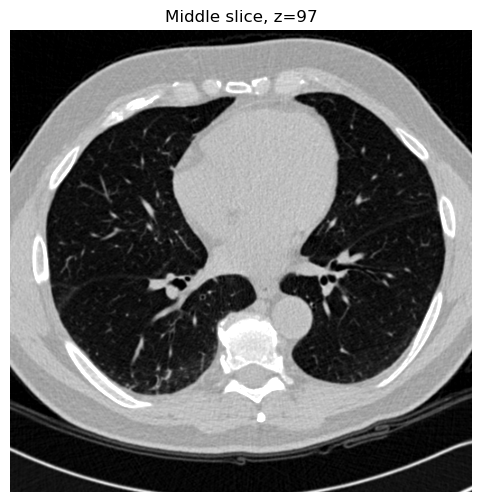

In [23]:
z = volume.shape[0] // 2

plt.figure(figsize=(6, 6))
plt.imshow(volume[z], cmap="gray", vmin=-1000, vmax=400)
plt.title(f"Middle slice, z={z}")
plt.axis("off")
plt.show()

In [24]:
# Release test volume before batch processing
del volume
gc.collect()

8585

In [25]:
def row_to_transform_matrix(row: pd.Series) -> np.ndarray:
    return np.array([
        [row["transform_00"], row["transform_01"], row["transform_02"]],
        [row["transform_10"], row["transform_11"], row["transform_12"]],
        [row["transform_20"], row["transform_21"], row["transform_22"]],
    ], dtype=np.float32)


def world_to_voxel(world_coord_xyz, origin_xyz, spacing_xyz, transform_matrix):
    '''
    Convert physical world coordinate [x, y, z] to voxel index.

    Returns:
        voxel_xyz: [x_index, y_index, z_index]
        voxel_zyx: [z_index, y_index, x_index] for NumPy indexing
    '''
    world_coord_xyz = np.asarray(world_coord_xyz, dtype=np.float32)
    origin_xyz = np.asarray(origin_xyz, dtype=np.float32)
    spacing_xyz = np.asarray(spacing_xyz, dtype=np.float32)
    transform_matrix = np.asarray(transform_matrix, dtype=np.float32).reshape(3, 3)

    relative = world_coord_xyz - origin_xyz
    voxel_continuous_xyz = np.linalg.inv(transform_matrix).dot(relative) / spacing_xyz

    voxel_xyz = np.round(voxel_continuous_xyz).astype(int)
    voxel_zyx = voxel_xyz[::-1]

    return voxel_xyz, voxel_zyx


def is_inside_volume_zyx(coord_zyx, shape_zyx):
    z, y, x = coord_zyx
    return (
        0 <= z < shape_zyx[0]
        and 0 <= y < shape_zyx[1]
        and 0 <= x < shape_zyx[2]
    )

In [26]:
ann = annotations.iloc[0]
seriesuid = ann["seriesuid"]
world_coord = [ann["coordX"], ann["coordY"], ann["coordZ"]]

volume, info = read_luna_volume_by_seriesuid(metadata_df, seriesuid)

voxel_xyz, voxel_zyx = world_to_voxel(
    world_coord_xyz=world_coord,
    origin_xyz=info.origin_xyz,
    spacing_xyz=info.spacing_xyz,
    transform_matrix=info.transform_matrix
)

print("SeriesUID:", seriesuid)
print("World coordinate [x, y, z]:", world_coord)
print("Voxel coordinate [x, y, z]:", voxel_xyz)
print("NumPy coordinate [z, y, x]:", voxel_zyx)
print("Volume shape [z, y, x]:", volume.shape)

print("Inside volume:", is_inside_volume_zyx(voxel_zyx, volume.shape))

z, y, x = voxel_zyx
if is_inside_volume_zyx(voxel_zyx, volume.shape):
    print("HU at nodule centre:", volume[z, y, x])

del volume
gc.collect()

SeriesUID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860
World coordinate [x, y, z]: [-128.6994211, -175.3192718, -298.3875064]
Voxel coordinate [x, y, z]: [ 45 212  78]
NumPy coordinate [z, y, x]: [ 78 212  45]
Volume shape [z, y, x]: (194, 512, 512)
Inside volume: True
HU at nodule centre: 89


0

In [27]:
def resample_volume_to_spacing(
    volume_hu_zyx: np.ndarray,
    original_spacing_xyz: np.ndarray,
    target_spacing_xyz: np.ndarray = TARGET_SPACING_XYZ,
    order: int = 1
):
    '''
    Resample volume to target spacing.

    volume_hu_zyx: [z, y, x]
    original_spacing_xyz: [x, y, z]
    target_spacing_xyz: [x, y, z]
    '''
    original_spacing_zyx = original_spacing_xyz[::-1].astype(np.float32)
    target_spacing_zyx = target_spacing_xyz[::-1].astype(np.float32)

    original_shape_zyx = np.array(volume_hu_zyx.shape, dtype=np.float32)

    new_shape_zyx = np.round(
        original_shape_zyx * (original_spacing_zyx / target_spacing_zyx)
    ).astype(int)
    new_shape_zyx = np.maximum(new_shape_zyx, 1)

    resize_factor_zyx = new_shape_zyx / original_shape_zyx
    new_spacing_zyx = original_spacing_zyx / resize_factor_zyx

    resampled = ndimage.zoom(
        volume_hu_zyx,
        zoom=resize_factor_zyx,
        order=order
    )

    new_spacing_xyz = new_spacing_zyx[::-1].astype(np.float32)

    return resampled, new_spacing_xyz


def normalise_hu(
    volume_hu: np.ndarray,
    clip_min: int = HU_CLIP_MIN,
    clip_max: int = HU_CLIP_MAX
):
    '''
    Clip HU values and scale to [0, 1].
    '''
    volume = np.clip(volume_hu, clip_min, clip_max).astype(np.float32)
    volume = (volume - clip_min) / float(clip_max - clip_min)
    return volume.astype(np.float32)


def segment_lung_parenchyma(
    volume_hu_zyx: np.ndarray,
    threshold_hu: int = LUNG_THRESHOLD_HU,
    keep_largest_components: int = 2,
    min_component_size: int = 10_000
):
    '''
    3D threshold-based lung parenchyma segmentation.

    Steps:
    1. HU < threshold gives air-like voxels.
    2. Remove outside air connected to image borders.
    3. Keep largest internal air components.
    4. Morphological cleanup.
    5. Fill holes slice by slice.
    '''
    air_mask = volume_hu_zyx < threshold_hu

    labels = measure.label(air_mask, connectivity=1)

    border_labels = set()
    border_labels.update(np.unique(labels[0, :, :]).tolist())
    border_labels.update(np.unique(labels[-1, :, :]).tolist())
    border_labels.update(np.unique(labels[:, 0, :]).tolist())
    border_labels.update(np.unique(labels[:, -1, :]).tolist())
    border_labels.update(np.unique(labels[:, :, 0]).tolist())
    border_labels.update(np.unique(labels[:, :, -1]).tolist())
    border_labels.discard(0)

    internal_air = air_mask.copy()
    if len(border_labels) > 0:
        internal_air[np.isin(labels, list(border_labels))] = False

    # Fallback if 3D border removal is too aggressive
    if internal_air.sum() < min_component_size:
        internal_air = np.zeros_like(air_mask, dtype=bool)
        for z in range(air_mask.shape[0]):
            internal_air[z] = segmentation.clear_border(air_mask[z])

    labels_internal = measure.label(internal_air, connectivity=1)
    props = measure.regionprops(labels_internal)

    valid_props = [p for p in props if p.area >= min_component_size]
    valid_props = sorted(valid_props, key=lambda p: p.area, reverse=True)

    lung_mask = np.zeros_like(internal_air, dtype=bool)

    if len(valid_props) == 0:
        lung_mask = internal_air
    else:
        for p in valid_props[:keep_largest_components]:
            lung_mask[labels_internal == p.label] = True

    lung_mask = morphology.binary_closing(lung_mask, morphology.ball(2))
    lung_mask = morphology.binary_opening(lung_mask, morphology.ball(1))

    filled = np.zeros_like(lung_mask, dtype=bool)
    for z in range(lung_mask.shape[0]):
        filled[z] = ndimage.binary_fill_holes(lung_mask[z])

    return filled.astype(np.uint8)

In [28]:
def save_preprocessing_qc_figure(
    anonymised_id: str,
    original_hu_zyx: np.ndarray,
    resampled_hu_zyx: np.ndarray,
    normalised_zyx: np.ndarray,
    lung_mask_zyx: np.ndarray,
    output_path: Path
):
    z_orig = original_hu_zyx.shape[0] // 2
    z_res = resampled_hu_zyx.shape[0] // 2

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(original_hu_zyx[z_orig], cmap="gray", vmin=-1000, vmax=400)
    axes[0].set_title("Original HU")

    axes[1].imshow(resampled_hu_zyx[z_res], cmap="gray", vmin=-1000, vmax=400)
    axes[1].set_title("Resampled HU")

    axes[2].imshow(normalised_zyx[z_res], cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("HU normalised")

    axes[3].imshow(resampled_hu_zyx[z_res], cmap="gray", vmin=-1000, vmax=400)
    axes[3].imshow(lung_mask_zyx[z_res], alpha=0.35)
    axes[3].set_title("Lung mask overlay")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(anonymised_id)
    plt.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=200)
    plt.show()
    plt.close()

SeriesUID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860
Anonymised ID: luna_225eb1547cd0
Original shape: (194, 512, 512)
Original spacing xyz: [0.64453125 0.64453125 1.8       ]
Resampled shape: (349, 330, 330)
New spacing xyz: [1.       1.       1.000573]
Normalised range: 0.0 1.0
Lung fraction: 0.000286769755381373


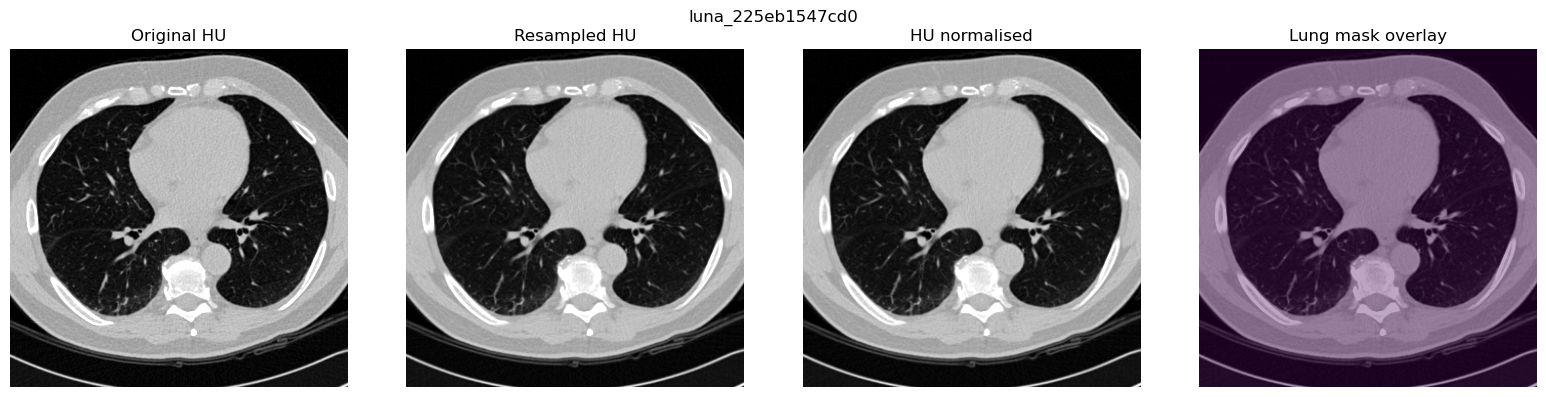

10657

In [29]:
# Test one preprocessing example

test_seriesuid = annotations.iloc[0]["seriesuid"]

original_volume, info = read_luna_volume_by_seriesuid(metadata_df, test_seriesuid)
original_hu = original_volume.astype(np.int16, copy=False)

resampled_hu, new_spacing_xyz = resample_volume_to_spacing(
    original_hu,
    original_spacing_xyz=info.spacing_xyz,
    target_spacing_xyz=TARGET_SPACING_XYZ,
    order=1
)

resampled_hu = resampled_hu.astype(np.float32)
normalised = normalise_hu(resampled_hu)
lung_mask = segment_lung_parenchyma(resampled_hu)

print("SeriesUID:", test_seriesuid)
print("Anonymised ID:", info.anonymised_id)
print("Original shape:", original_hu.shape)
print("Original spacing xyz:", info.spacing_xyz)
print("Resampled shape:", resampled_hu.shape)
print("New spacing xyz:", new_spacing_xyz)
print("Normalised range:", normalised.min(), normalised.max())
print("Lung fraction:", lung_mask.sum() / lung_mask.size)

save_preprocessing_qc_figure(
    anonymised_id=info.anonymised_id,
    original_hu_zyx=original_hu,
    resampled_hu_zyx=resampled_hu,
    normalised_zyx=normalised,
    lung_mask_zyx=lung_mask,
    output_path=LUNA_QC_FIGURE_DIR / f"{info.anonymised_id}_single_scan_qc.png"
)

del original_volume, original_hu, resampled_hu, normalised, lung_mask
gc.collect()

In [30]:
def preprocess_single_scan(
    metadata_df: pd.DataFrame,
    seriesuid: str,
    save_full_volume: bool = SAVE_FULL_PREPROCESSED_VOLUME,
    save_qc_figure: bool = True
):
    original_volume, info = read_luna_volume_by_seriesuid(metadata_df, seriesuid)
    original_hu = original_volume.astype(np.int16, copy=False)

    original_shape = tuple(int(x) for x in original_hu.shape)
    original_spacing_xyz = info.spacing_xyz.copy()

    resampled_hu, new_spacing_xyz = resample_volume_to_spacing(
        original_hu,
        original_spacing_xyz=original_spacing_xyz,
        target_spacing_xyz=TARGET_SPACING_XYZ,
        order=1
    )

    resampled_hu = resampled_hu.astype(np.float32)
    normalised = normalise_hu(resampled_hu)
    lung_mask = segment_lung_parenchyma(resampled_hu)

    lung_voxels = int(lung_mask.sum())
    total_voxels = int(lung_mask.size)
    lung_fraction = float(lung_voxels / total_voxels) if total_voxels > 0 else 0.0

    anonymised_id = info.anonymised_id

    saved_output_meta = None

    if save_full_volume:
        LUNA_PREPROCESSED_VOLUME_DIR.mkdir(parents=True, exist_ok=True)
        output_npz = LUNA_PREPROCESSED_VOLUME_DIR / f"{anonymised_id}.npz"

        np.savez_compressed(
            output_npz,
            image=normalised.astype(np.float16),
            lung_mask=lung_mask.astype(np.uint8),
            spacing_xyz=new_spacing_xyz.astype(np.float32),
            origin_xyz=info.origin_xyz.astype(np.float32),
            transform_matrix=info.transform_matrix.astype(np.float32),
        )

        saved_output_meta = {
            "anonymised_id": anonymised_id,
            "output_npz": str(output_npz),
            "saved_full_volume": True
        }

    if save_qc_figure:
        qc_path = LUNA_QC_FIGURE_DIR / f"{anonymised_id}_qc.png"
        save_preprocessing_qc_figure(
            anonymised_id=anonymised_id,
            original_hu_zyx=original_hu,
            resampled_hu_zyx=resampled_hu,
            normalised_zyx=normalised,
            lung_mask_zyx=lung_mask,
            output_path=qc_path
        )

    scan_summary = {
        "seriesuid": seriesuid,
        "anonymised_id": anonymised_id,

        "original_shape_z": original_shape[0],
        "original_shape_y": original_shape[1],
        "original_shape_x": original_shape[2],

        "original_spacing_x": float(original_spacing_xyz[0]),
        "original_spacing_y": float(original_spacing_xyz[1]),
        "original_spacing_z": float(original_spacing_xyz[2]),

        "resampled_shape_z": int(resampled_hu.shape[0]),
        "resampled_shape_y": int(resampled_hu.shape[1]),
        "resampled_shape_x": int(resampled_hu.shape[2]),

        "new_spacing_x": float(new_spacing_xyz[0]),
        "new_spacing_y": float(new_spacing_xyz[1]),
        "new_spacing_z": float(new_spacing_xyz[2]),

        "original_hu_min": float(np.min(original_hu)),
        "original_hu_max": float(np.max(original_hu)),
        "original_hu_mean": float(np.mean(original_hu)),

        "resampled_hu_min": float(np.min(resampled_hu)),
        "resampled_hu_max": float(np.max(resampled_hu)),
        "resampled_hu_mean": float(np.mean(resampled_hu)),

        "normalised_min": float(np.min(normalised)),
        "normalised_max": float(np.max(normalised)),
        "normalised_mean": float(np.mean(normalised)),

        "lung_voxels": lung_voxels,
        "total_voxels": total_voxels,
        "lung_fraction": lung_fraction,

        "saved_full_volume": bool(save_full_volume),
    }

    del original_volume, original_hu, resampled_hu, normalised, lung_mask
    gc.collect()

    return scan_summary, saved_output_meta

In [31]:
def validate_annotation_coordinates_for_scan(
    metadata_df: pd.DataFrame,
    annotations: pd.DataFrame,
    seriesuid: str,
    resampled_spacing_xyz: np.ndarray
):
    row = metadata_df[metadata_df["seriesuid"] == seriesuid].iloc[0]

    original_shape_zyx = np.array([row["size_z"], row["size_y"], row["size_x"]], dtype=int)
    original_spacing_xyz = np.array([row["spacing_x"], row["spacing_y"], row["spacing_z"]], dtype=np.float32)
    origin_xyz = np.array([row["origin_x"], row["origin_y"], row["origin_z"]], dtype=np.float32)
    transform_matrix = row_to_transform_matrix(row)

    original_shape_zyx_float = original_shape_zyx.astype(np.float32)
    original_spacing_zyx = original_spacing_xyz[::-1]
    resampled_spacing_zyx = resampled_spacing_xyz[::-1]

    expected_resampled_shape_zyx = np.round(
        original_shape_zyx_float * (original_spacing_zyx / resampled_spacing_zyx)
    ).astype(int)

    ann_rows = annotations[annotations["seriesuid"] == seriesuid]

    rows = []

    for _, ann in ann_rows.iterrows():
        world_coord = np.array([ann["coordX"], ann["coordY"], ann["coordZ"]], dtype=np.float32)

        original_voxel_xyz, original_voxel_zyx = world_to_voxel(
            world_coord_xyz=world_coord,
            origin_xyz=origin_xyz,
            spacing_xyz=original_spacing_xyz,
            transform_matrix=transform_matrix
        )

        resampled_voxel_xyz, resampled_voxel_zyx = world_to_voxel(
            world_coord_xyz=world_coord,
            origin_xyz=origin_xyz,
            spacing_xyz=resampled_spacing_xyz,
            transform_matrix=transform_matrix
        )

        rows.append({
            "seriesuid": seriesuid,
            "anonymised_id": sha1_anonymise(seriesuid),
            "coordX": float(ann["coordX"]),
            "coordY": float(ann["coordY"]),
            "coordZ": float(ann["coordZ"]),
            "diameter_mm": float(ann["diameter_mm"]),

            "original_voxel_x": int(original_voxel_xyz[0]),
            "original_voxel_y": int(original_voxel_xyz[1]),
            "original_voxel_z": int(original_voxel_xyz[2]),
            "original_inside_volume": is_inside_volume_zyx(original_voxel_zyx, tuple(original_shape_zyx)),

            "resampled_voxel_x": int(resampled_voxel_xyz[0]),
            "resampled_voxel_y": int(resampled_voxel_xyz[1]),
            "resampled_voxel_z": int(resampled_voxel_xyz[2]),
            "resampled_inside_volume": is_inside_volume_zyx(
                resampled_voxel_zyx,
                tuple(expected_resampled_shape_zyx)
            ),
        })

    return pd.DataFrame(rows)

In [32]:
def choose_scans_for_preprocessing(metadata_df: pd.DataFrame, annotations: pd.DataFrame):
    if PROCESS_ONLY_SCANS_WITH_NODULES_FIRST:
        seriesuids = sorted(annotations["seriesuid"].unique().tolist())
    else:
        seriesuids = sorted(metadata_df["seriesuid"].unique().tolist())

    if MAX_SCANS_TO_PREPROCESS is not None:
        seriesuids = seriesuids[:MAX_SCANS_TO_PREPROCESS]

    return seriesuids


seriesuids_to_process = choose_scans_for_preprocessing(metadata_df, annotations)

print("Scans selected for preprocessing:", len(seriesuids_to_process))
print("First 10:", seriesuids_to_process[:10])

Scans selected for preprocessing: 10
First 10: ['1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860', '1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793540579077826395208', '1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016233746780170740405', '1.3.6.1.4.1.14519.5.2.1.6279.6001.100953483028192176989979435275', '1.3.6.1.4.1.14519.5.2.1.6279.6001.102681962408431413578140925249', '1.3.6.1.4.1.14519.5.2.1.6279.6001.104562737760173137525888934217', '1.3.6.1.4.1.14519.5.2.1.6279.6001.105495028985881418176186711228', '1.3.6.1.4.1.14519.5.2.1.6279.6001.106164978370116976238911317774', '1.3.6.1.4.1.14519.5.2.1.6279.6001.106379658920626694402549886949', '1.3.6.1.4.1.14519.5.2.1.6279.6001.106630482085576298661469304872']


Preprocessing CT scans:   0%|          | 0/10 [00:00<?, ?it/s]

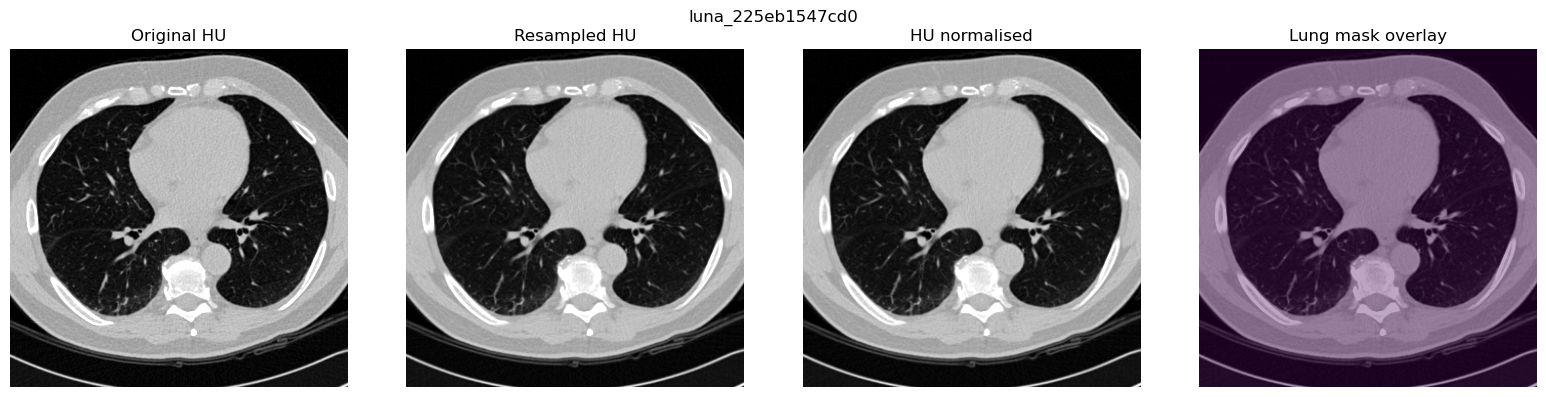

Preprocessing CT scans:  10%|█         | 1/10 [00:13<01:58, 13.22s/it]

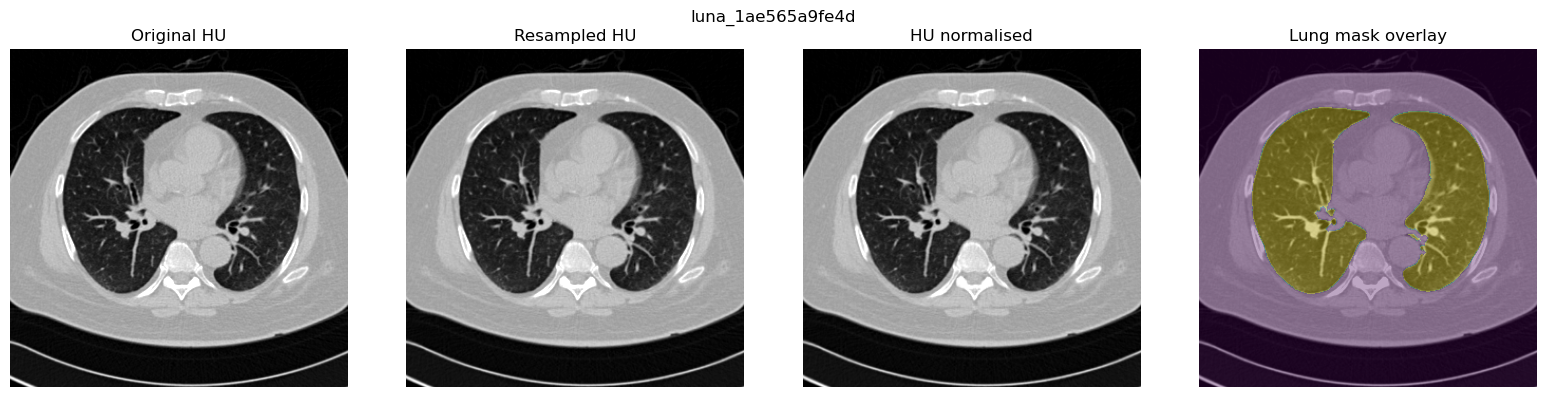

Preprocessing CT scans:  20%|██        | 2/10 [00:23<01:31, 11.48s/it]

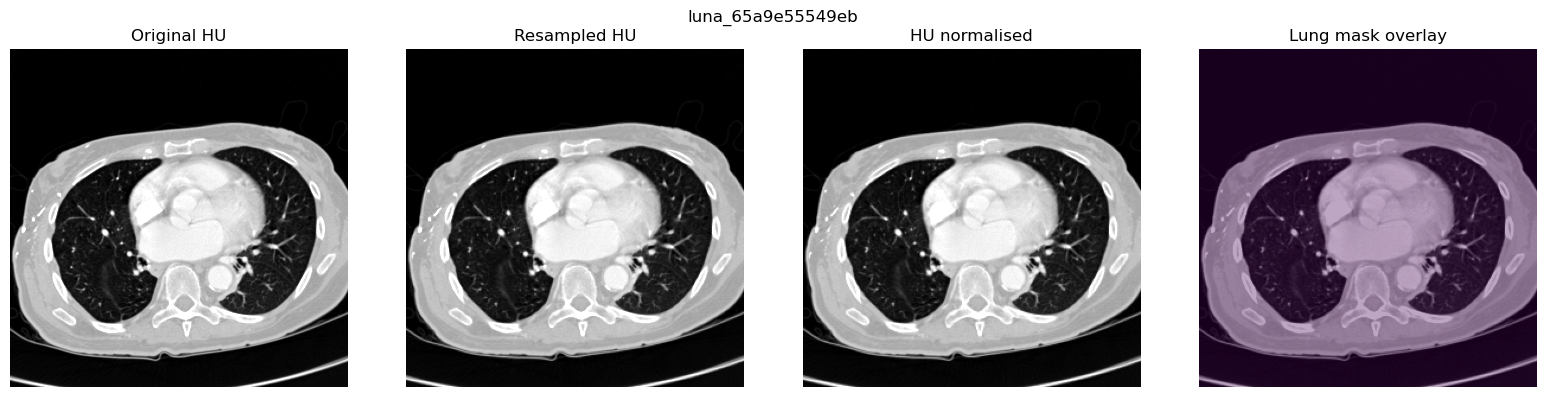

Preprocessing CT scans:  30%|███       | 3/10 [00:32<01:12, 10.36s/it]

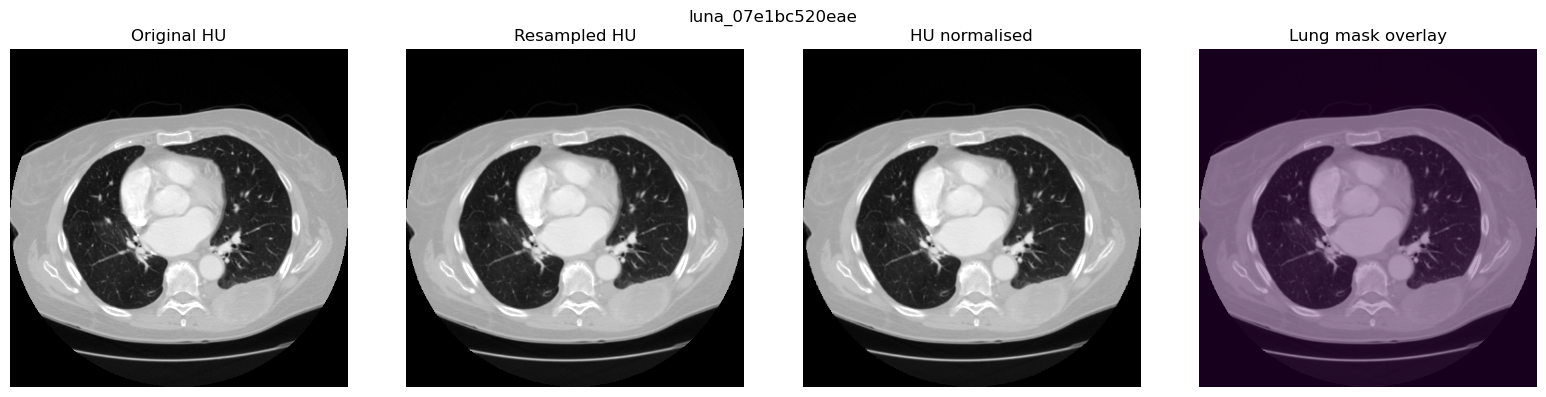

Preprocessing CT scans:  40%|████      | 4/10 [00:43<01:04, 10.74s/it]

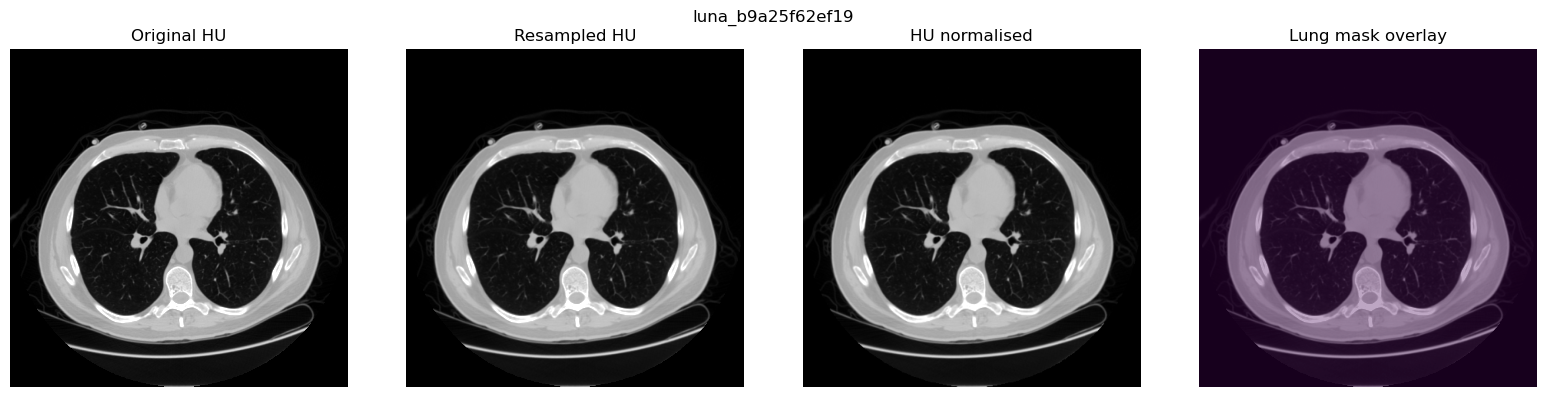

Preprocessing CT scans:  50%|█████     | 5/10 [01:01<01:05, 13.15s/it]

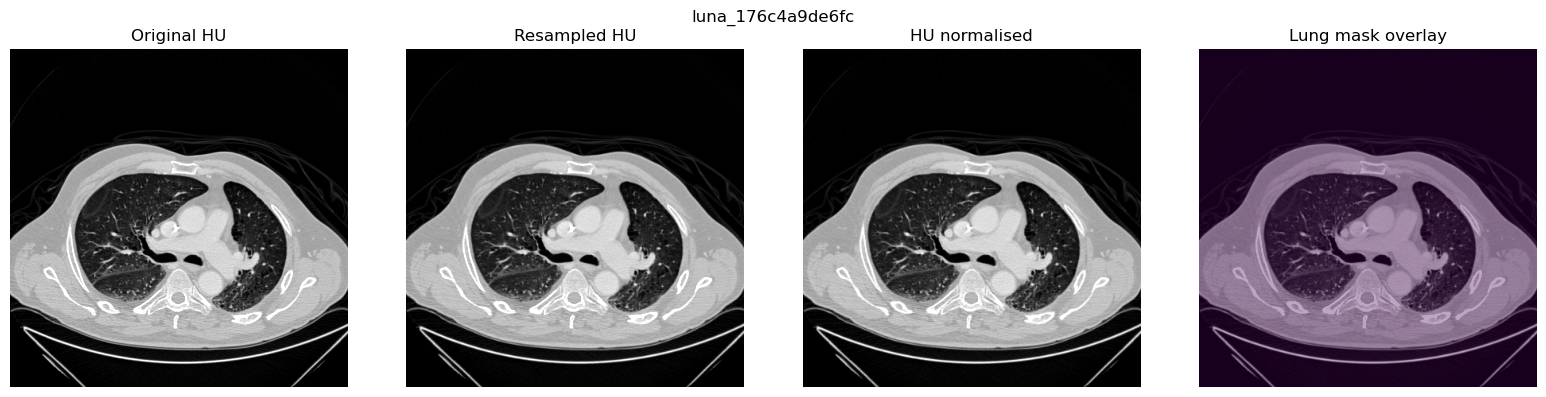

Preprocessing CT scans:  60%|██████    | 6/10 [01:14<00:52, 13.25s/it]

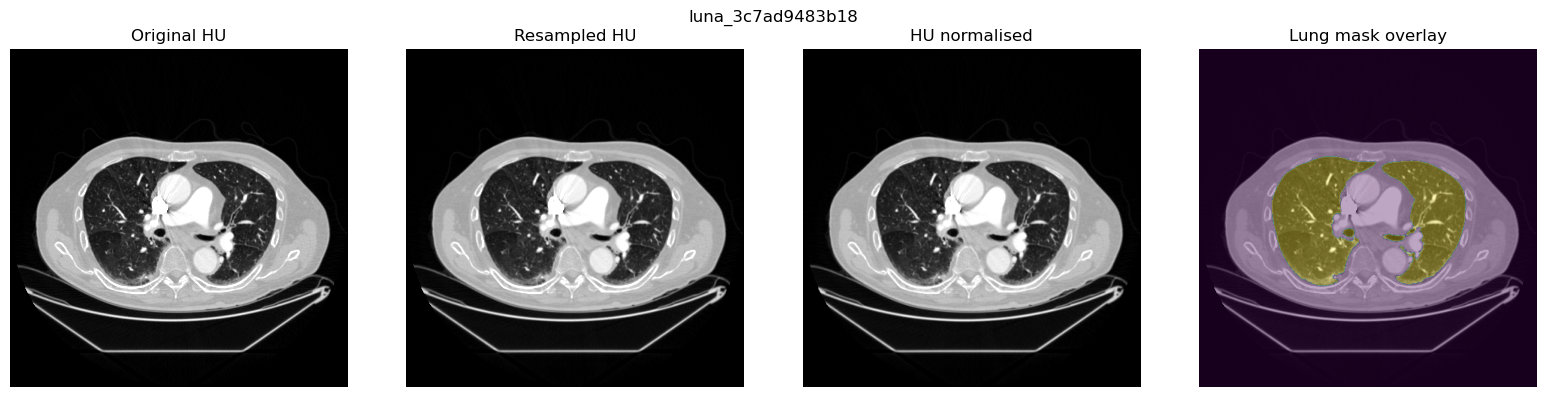

Preprocessing CT scans:  70%|███████   | 7/10 [01:28<00:39, 13.33s/it]

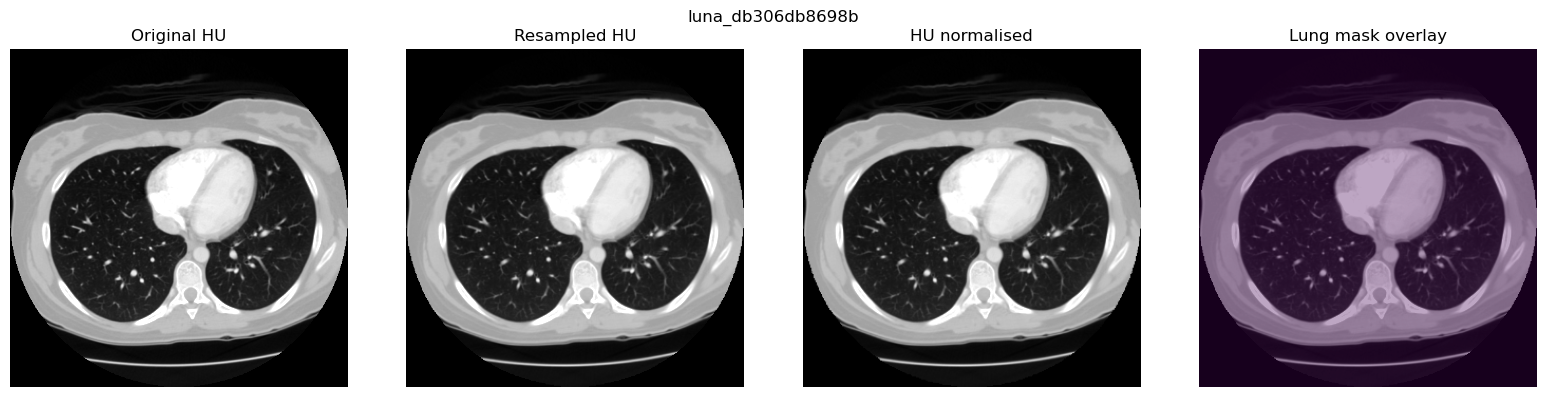

Preprocessing CT scans:  80%|████████  | 8/10 [01:37<00:23, 11.97s/it]

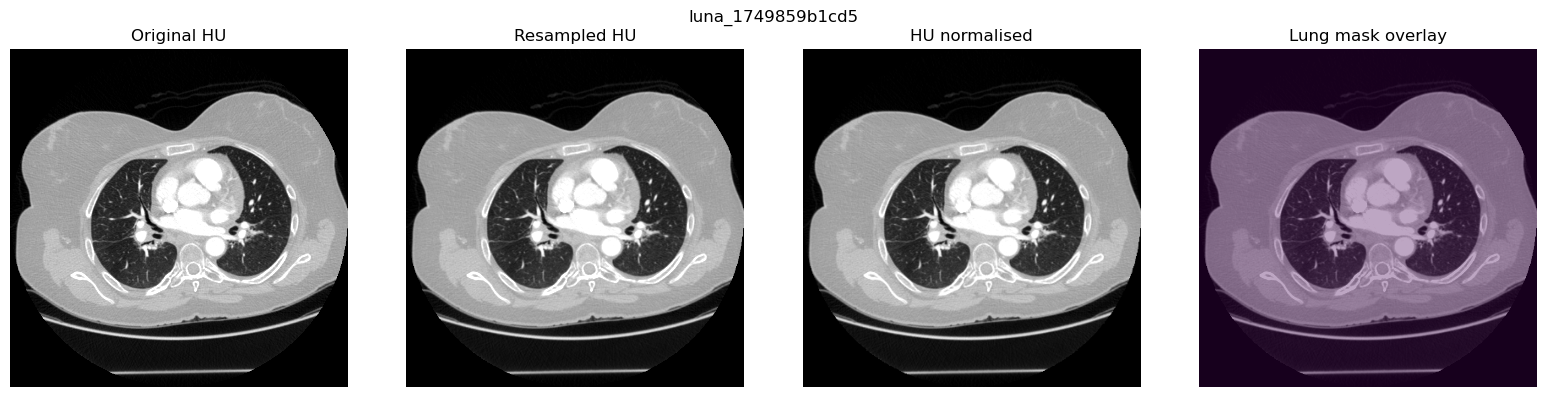

Preprocessing CT scans:  90%|█████████ | 9/10 [01:49<00:11, 11.96s/it]

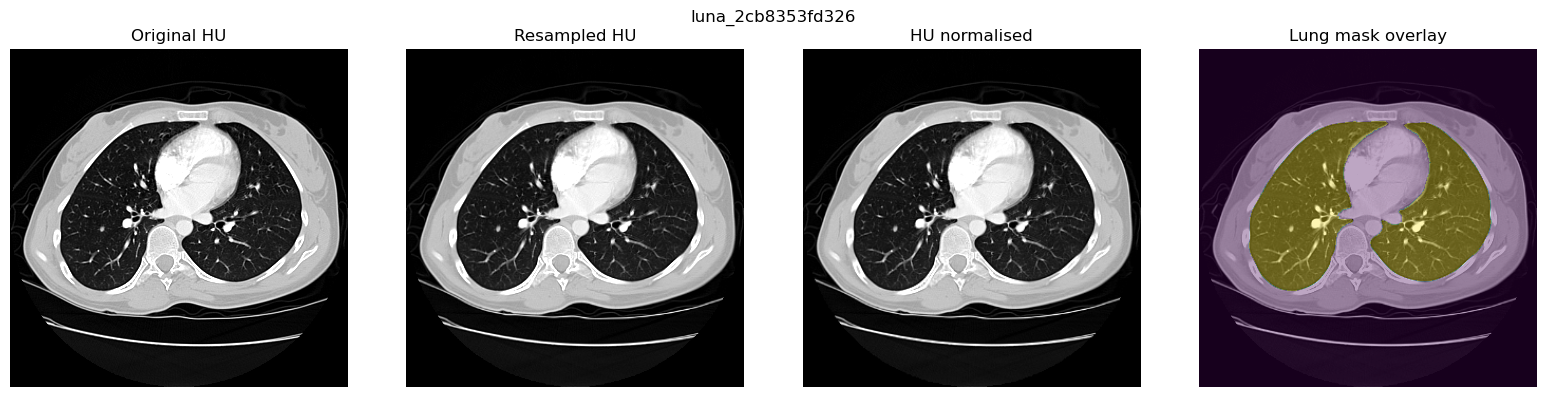

Preprocessing CT scans: 100%|██████████| 10/10 [02:00<00:00, 12.05s/it]


,seriesuid,anonymised_id,original_shape_z,original_shape_y,original_shape_x,original_spacing_x,original_spacing_y,original_spacing_z,resampled_shape_z,resampled_shape_y,...,resampled_hu_min,resampled_hu_max,resampled_hu_mean,normalised_min,normalised_max,normalised_mean,lung_voxels,total_voxels,lung_fraction,saved_full_volume
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,luna_225eb1547cd0,194,512,512,0.644531,0.644531,1.8,349,330,...,-1024.0,2861.0,-370.044373,0.0,1.0,0.447066,10899,38006100,0.000287,False
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,luna_1ae565a9fe4d,157,512,512,0.625000,0.625000,1.8,283,320,...,-1024.0,1573.0,-398.070312,0.0,1.0,0.428788,3424645,28979200,0.118176,False
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,luna_65a9e55549eb,321,512,512,0.556641,0.556641,1.0,321,285,...,-1000.0,3000.0,-514.957153,0.0,1.0,0.342140,34499,26073225,0.001323,False
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100953483028...,luna_07e1bc520eae,133,512,512,0.703125,0.703125,2.5,332,360,...,-2048.0,3071.0,-747.492615,0.0,1.0,0.339153,10429,43027200,0.000242,False
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.102681962408...,luna_b9a25f62ef19,143,512,512,0.859375,0.859375,2.5,358,440,...,-2048.0,3071.0,-889.151917,0.0,1.0,0.237761,26027,69308800,0.000376,False


,seriesuid,anonymised_id,coordX,coordY,coordZ,diameter_mm,original_voxel_x,original_voxel_y,original_voxel_z,original_inside_volume,resampled_voxel_x,resampled_voxel_y,resampled_voxel_z,resampled_inside_volume
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,luna_225eb1547cd0,-128.699421,-175.319272,-298.387506,5.651471,45,212,78,True,29,136,140,True
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,luna_225eb1547cd0,103.783651,-211.925149,-227.121250,4.224708,406,155,117,True,261,100,211,True
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,luna_1ae565a9fe4d,69.639017,-140.944586,876.374496,5.786348,385,270,89,True,240,169,160,True
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,luna_65a9e55549eb,-24.013824,192.102405,-391.081276,8.143262,173,328,266,True,96,183,266,True
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,luna_65a9e55549eb,2.441547,172.464881,-405.493732,18.545150,220,293,252,True,122,163,252,True


Saved preprocessing summary: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\tables\luna16\preprocessing_validation_summary.csv
Saved coordinate validation: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\tables\luna16\annotation_coordinate_validation.csv
Saved de-identification mapping: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\tables\luna16\deidentification_mapping_controlled.csv


In [33]:
preprocessing_rows = []
saved_volume_rows = []
coordinate_validation_rows = []

for i, seriesuid in enumerate(tqdm(seriesuids_to_process, desc="Preprocessing CT scans")):
    try:
        save_qc = i < MAX_QC_FIGURES

        summary, saved_meta = preprocess_single_scan(
            metadata_df=metadata_df,
            seriesuid=seriesuid,
            save_full_volume=SAVE_FULL_PREPROCESSED_VOLUME,
            save_qc_figure=save_qc
        )

        preprocessing_rows.append(summary)

        if saved_meta is not None:
            saved_volume_rows.append(saved_meta)

        resampled_spacing_xyz = np.array([
            summary["new_spacing_x"],
            summary["new_spacing_y"],
            summary["new_spacing_z"],
        ], dtype=np.float32)

        coord_df = validate_annotation_coordinates_for_scan(
            metadata_df=metadata_df,
            annotations=annotations,
            seriesuid=seriesuid,
            resampled_spacing_xyz=resampled_spacing_xyz
        )

        if len(coord_df) > 0:
            coordinate_validation_rows.append(coord_df)

    except Exception as e:
        print(f"Failed to preprocess {seriesuid}: {repr(e)}")
        preprocessing_rows.append({
            "seriesuid": seriesuid,
            "anonymised_id": sha1_anonymise(seriesuid),
            "error": repr(e)
        })

preprocessing_df = pd.DataFrame(preprocessing_rows)
display(preprocessing_df.head())

preprocessing_df.to_csv(
    LUNA_TABLE_DIR / "preprocessing_validation_summary.csv",
    index=False
)

if len(saved_volume_rows) > 0:
    saved_volume_df = pd.DataFrame(saved_volume_rows)
    saved_volume_df.to_csv(
        LUNA_TABLE_DIR / "saved_preprocessed_volume_index.csv",
        index=False
    )

if len(coordinate_validation_rows) > 0:
    coordinate_validation_df = pd.concat(coordinate_validation_rows, ignore_index=True)
else:
    coordinate_validation_df = pd.DataFrame()

display(coordinate_validation_df.head())

coordinate_validation_df.to_csv(
    LUNA_TABLE_DIR / "annotation_coordinate_validation.csv",
    index=False
)

deid_mapping_df = pd.DataFrame({
    "seriesuid": seriesuids_to_process,
    "anonymised_id": [sha1_anonymise(x) for x in seriesuids_to_process]
})

deid_mapping_df.to_csv(
    LUNA_TABLE_DIR / "deidentification_mapping_controlled.csv",
    index=False
)

print("Saved preprocessing summary:", LUNA_TABLE_DIR / "preprocessing_validation_summary.csv")
print("Saved coordinate validation:", LUNA_TABLE_DIR / "annotation_coordinate_validation.csv")
print("Saved de-identification mapping:", LUNA_TABLE_DIR / "deidentification_mapping_controlled.csv")

In [34]:
if "error" in preprocessing_df.columns:
    successful_df = preprocessing_df[preprocessing_df["error"].isna()].copy()
else:
    successful_df = preprocessing_df.copy()

print("Attempted scans:", len(preprocessing_df))
print("Successful scans:", len(successful_df))

if len(successful_df) > 0:
    print("\nLung fraction:")
    display(successful_df["lung_fraction"].describe())

    print("\nNormalised intensity mean:")
    display(successful_df["normalised_mean"].describe())

    print("\nResampled shape:")
    display(successful_df[["resampled_shape_z", "resampled_shape_y", "resampled_shape_x"]].describe())

if len(coordinate_validation_df) > 0:
    print("\nCoordinate validation:")
    print("Original inside volume %:", coordinate_validation_df["original_inside_volume"].mean() * 100)
    print("Resampled inside volume %:", coordinate_validation_df["resampled_inside_volume"].mean() * 100)

Attempted scans: 10
Successful scans: 10

Lung fraction:


count    10.000000
mean      0.029648
std       0.049335
min       0.000242
25%       0.000304
50%       0.000391
75%       0.046100
max       0.118176
Name: lung_fraction, dtype: float64


Normalised intensity mean:


count    10.000000
mean      0.327900
std       0.068848
min       0.237761
25%       0.278207
50%       0.328691
75%       0.341394
max       0.447066
Name: normalised_mean, dtype: float64


Resampled shape:


,resampled_shape_z,resampled_shape_y,resampled_shape_x
count,10.000000,10.000000,10.000000
mean,314.100000,365.000000,365.000000
std,35.750524,59.066817,59.066817
min,268.000000,285.000000,285.000000
25%,280.750000,320.000000,320.000000
50%,326.500000,345.000000,345.000000
75%,344.750000,418.750000,418.750000
max,358.000000,450.000000,450.000000



Coordinate validation:
Original inside volume %: 100.0
Resampled inside volume %: 100.0


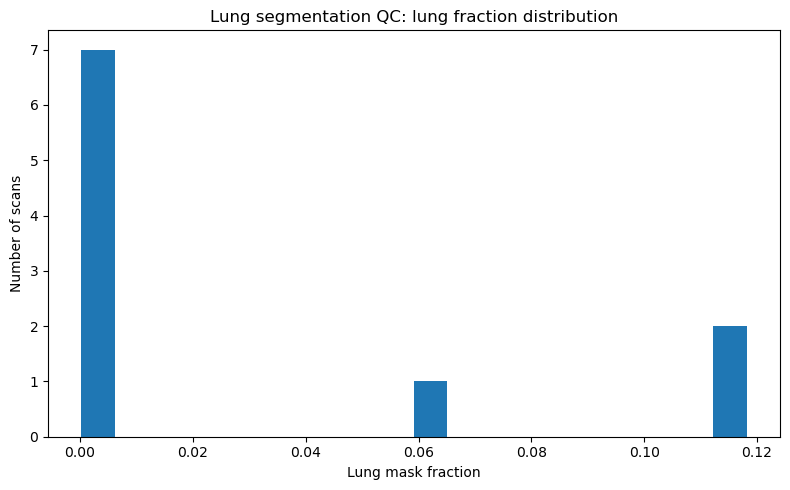

In [35]:
if len(successful_df) > 0:
    plt.figure(figsize=(8, 5))
    plt.hist(successful_df["lung_fraction"], bins=20)
    plt.xlabel("Lung mask fraction")
    plt.ylabel("Number of scans")
    plt.title("Lung segmentation QC: lung fraction distribution")
    plt.tight_layout()
    plt.savefig(LUNA_FIGURE_DIR / "lung_fraction_distribution.png", dpi=300)
    plt.show()

In [36]:
preprocessing_report_path = LUNA_TABLE_DIR / "luna16_preprocessing_validation_report.md"

with open(preprocessing_report_path, "w", encoding="utf-8") as f:
    f.write("# LUNA16 Preprocessing Pipeline Validation Report\n\n")

    f.write("## Pipeline scope\n\n")
    f.write("- Zip-based reading of `.mhd` and `.raw` files without full dataset extraction.\n")
    f.write("- De-identification through anonymised output identifiers.\n")
    f.write("- Resampling to standard voxel spacing.\n")
    f.write("- HU clipping and normalisation.\n")
    f.write("- Threshold-based lung parenchyma segmentation.\n")
    f.write("- Coordinate validation for annotation points.\n\n")

    f.write("## Parameters\n\n")
    f.write(f"- Target spacing XYZ: {TARGET_SPACING_XYZ.tolist()} mm\n")
    f.write(f"- HU clip range: [{HU_CLIP_MIN}, {HU_CLIP_MAX}]\n")
    f.write(f"- Lung segmentation threshold: {LUNG_THRESHOLD_HU} HU\n")
    f.write(f"- Save full preprocessed volume: {SAVE_FULL_PREPROCESSED_VOLUME}\n\n")

    f.write("## Processed scan summary\n\n")
    f.write(f"- Number of attempted scans: {len(preprocessing_df)}\n")
    f.write(f"- Number of successful scans: {len(successful_df)}\n")
    if "error" in preprocessing_df.columns:
        f.write(f"- Number of failed scans: {preprocessing_df['error'].notna().sum()}\n")
    f.write("\n")

    if len(successful_df) > 0:
        f.write("## QC metrics\n\n")
        f.write(f"- Mean lung fraction: {successful_df['lung_fraction'].mean():.4f}\n")
        f.write(f"- Median lung fraction: {successful_df['lung_fraction'].median():.4f}\n")
        f.write(f"- Mean normalised intensity: {successful_df['normalised_mean'].mean():.4f}\n")
        f.write(f"- Mean resampled z-size: {successful_df['resampled_shape_z'].mean():.2f}\n\n")

    if len(coordinate_validation_df) > 0:
        f.write("## Annotation coordinate validation\n\n")
        f.write(f"- Annotation points checked: {len(coordinate_validation_df)}\n")
        f.write(
            f"- Original coordinates inside volume: "
            f"{coordinate_validation_df['original_inside_volume'].mean() * 100:.2f}%\n"
        )
        f.write(
            f"- Resampled coordinates inside volume: "
            f"{coordinate_validation_df['resampled_inside_volume'].mean() * 100:.2f}%\n"
        )

print("Saved:", preprocessing_report_path)

Saved: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\tables\luna16\luna16_preprocessing_validation_report.md


In [37]:
def extract_roi_3d(volume, center_zyx, roi_size=64, pad_value=-1000):
    zc, yc, xc = [int(v) for v in center_zyx]
    half = roi_size // 2

    z_min, z_max = zc - half, zc + half
    y_min, y_max = yc - half, yc + half
    x_min, x_max = xc - half, xc + half

    pad_z_before = max(0, -z_min)
    pad_y_before = max(0, -y_min)
    pad_x_before = max(0, -x_min)

    pad_z_after = max(0, z_max - volume.shape[0])
    pad_y_after = max(0, y_max - volume.shape[1])
    pad_x_after = max(0, x_max - volume.shape[2])

    z_min = max(0, z_min)
    y_min = max(0, y_min)
    x_min = max(0, x_min)

    z_max = min(volume.shape[0], z_max)
    y_max = min(volume.shape[1], y_max)
    x_max = min(volume.shape[2], x_max)

    roi = volume[z_min:z_max, y_min:y_max, x_min:x_max]

    roi = np.pad(
        roi,
        pad_width=(
            (pad_z_before, pad_z_after),
            (pad_y_before, pad_y_after),
            (pad_x_before, pad_x_after)
        ),
        mode="constant",
        constant_values=pad_value
    )

    return roi

SeriesUID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860
ROI shape: (64, 64, 64)
ROI HU range: -1024 1298


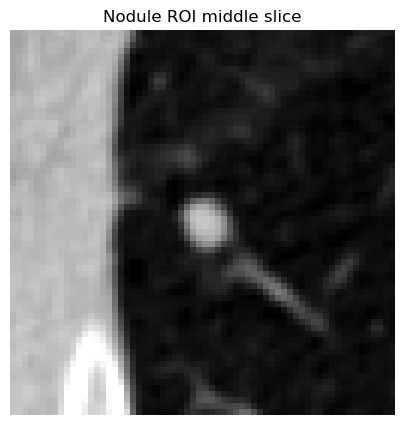

2857

In [38]:
# Example ROI extraction from one annotation

ann = annotations.iloc[0]
seriesuid = ann["seriesuid"]

volume, info = read_luna_volume_by_seriesuid(metadata_df, seriesuid)

world_coord = [ann["coordX"], ann["coordY"], ann["coordZ"]]

voxel_xyz, voxel_zyx = world_to_voxel(
    world_coord_xyz=world_coord,
    origin_xyz=info.origin_xyz,
    spacing_xyz=info.spacing_xyz,
    transform_matrix=info.transform_matrix
)

roi = extract_roi_3d(volume, voxel_zyx, roi_size=64)

print("SeriesUID:", seriesuid)
print("ROI shape:", roi.shape)
print("ROI HU range:", roi.min(), roi.max())

plt.figure(figsize=(5, 5))
plt.imshow(roi[roi.shape[0] // 2], cmap="gray", vmin=-1000, vmax=400)
plt.title("Nodule ROI middle slice")
plt.axis("off")
plt.show()

del volume, roi
gc.collect()